In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [182]:
clients = pd.read_csv("../data/clients.csv")
properties = pd.read_csv("../data/properties.csv")

In [183]:
print("Clients Dataset:")
print(clients.shape)

print("\nProperties Dataset:")
print(properties.shape)

Clients Dataset:
(2000, 12)

Properties Dataset:
(10000, 9)


In [94]:
display(clients.head())

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [95]:
display(properties.head())

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [96]:
print("Clients Columns:")
print(clients.columns.tolist())

Clients Columns:
['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel']


In [97]:
print("Properties Columns:")
print(properties.columns.tolist())

Properties Columns:
['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']


In [98]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [99]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.2+ KB


In [100]:
clients.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [101]:
properties.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [102]:
print("Duplicate clients:", clients.duplicated().sum())

Duplicate clients: 0


In [103]:
print("Duplicate properties:", properties.duplicated().sum())

Duplicate properties: 0


In [104]:
clients.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')

In [105]:
clients["client_type"].unique()

array(['Individual', 'Company'], dtype=object)

In [106]:
clients["gender"].unique()

array(['F', 'M'], dtype=object)

In [107]:
clients["acquisition_purpose"].unique()

array(['Home', 'Investment'], dtype=object)

In [108]:
clients["loan_applied"].unique()

array(['Yes', 'No'], dtype=object)

In [109]:
clients.describe()

,satisfaction_score
count,2000.000000
mean,3.029000
std,1.413562
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [110]:
clients_clean = clients.copy()

In [111]:
clients_clean["client_id"].duplicated().sum()

np.int64(0)

In [112]:
print("Client Type:")
print(clients_clean["client_type"].value_counts())

print("\nGender:")
print(clients_clean["gender"].value_counts())

print("\nAcquisition Purpose:")
print(clients_clean["acquisition_purpose"].value_counts())

print("\nLoan Applied:")
print(clients_clean["loan_applied"].value_counts())

print("\nReferral Channel:")
print(clients_clean["referral_channel"].value_counts())

Client Type:
client_type
Individual    1897
Company        103
Name: count, dtype: int64

Gender:
gender
M    1012
F     988
Name: count, dtype: int64

Acquisition Purpose:
acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

Loan Applied:
loan_applied
No     1264
Yes     736
Name: count, dtype: int64

Referral Channel:
referral_channel
Website    1103
Agency      705
Client      192
Name: count, dtype: int64


In [113]:
clients_clean["date_of_birth"] = pd.to_datetime(
    clients_clean["date_of_birth"],
    errors="coerce"
)

In [114]:
clients_clean["date_of_birth"].isnull().sum()

np.int64(1145)

In [115]:
clients_clean["date_of_birth"] = pd.to_datetime(
    clients["date_of_birth"],
    format="mixed",
    errors="coerce"
)

In [116]:
clients_clean["date_of_birth"].isnull().sum()

np.int64(0)

In [117]:
today = pd.Timestamp.today()

clients_clean["age"] = (
    today.year
    - clients_clean["date_of_birth"].dt.year
    - (
        (today.month < clients_clean["date_of_birth"].dt.month)
        | (
            (today.month == clients_clean["date_of_birth"].dt.month)
            & (today.day < clients_clean["date_of_birth"].dt.day)
        )
    )
)

In [118]:
clients_clean[["date_of_birth", "age"]].head()

,date_of_birth,age
0,1968-05-11,58
1,1962-11-26,63
2,1959-04-07,67
3,1959-11-25,66
4,1976-02-28,50


In [119]:
clients_clean["age"].describe()

count    2000.000000
mean       55.759500
std        17.360886
min        25.000000
25%        41.000000
50%        56.000000
75%        70.000000
max        95.000000
Name: age, dtype: float64

In [120]:
print("Minimum Age:", clients_clean["age"].min())
print("Maximum Age:", clients_clean["age"].max())

Minimum Age: 25
Maximum Age: 95


In [121]:
clients_clean.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50


In [122]:
# STEP-05

In [123]:
properties_clean = properties.copy()

In [124]:
properties_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.2+ KB


In [125]:
properties_clean.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [126]:
properties_clean.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [127]:
properties_clean["client_ref"].isnull().sum()

np.int64(2695)

In [128]:
properties_linked = properties_clean.dropna(subset=["client_ref"]).copy()

In [129]:
properties_linked.shape

(7305, 9)

In [130]:
properties_linked["transaction_date"] = pd.to_datetime(
     properties_linked["transaction_date"],
     format="mixed",
     errors="coerce"
)

In [131]:
properties_linked["transaction_date"].isnull().sum()

np.int64(0)

In [132]:
properties_linked["listing_id"].duplicated().sum()

np.int64(0)

In [133]:
properties_linked[
    ["floor_area_sqft","sale_price"]
    ].describe()     

,floor_area_sqft
count,7305.000000
mean,1141.147838
std,419.241645
min,410.710000
25%,782.150000
50%,1110.880000
75%,1501.640000
max,1957.160000


In [134]:
print("Minimum Floor Area:", properties_linked["floor_area_sqft"].min())
print("Minimum Sale Price:", properties_linked["sale_price"].min())

Minimum Floor Area: 410.71
Minimum Sale Price: $101,076.80


In [135]:
print("Unit Category:")
print(properties_linked["unit_category"].value_counts())

print("\nListing Status:")
print(properties_linked["listing_status"].value_counts())

print("\nTower Number:")
print(properties_linked["tower_number"].value_counts())

Unit Category:
unit_category
Apartment    6225
Office       1080
Name: count, dtype: int64

Listing Status:
listing_status
Sold    7305
Name: count, dtype: int64

Tower Number:
tower_number
2     441
13    430
18    428
3     419
11    400
9     391
7     387
15    369
14    366
20    365
6     350
5     350
1     349
8     344
4     339
17    329
10    325
19    322
12    305
16    296
Name: count, dtype: int64


In [136]:
# STEP-06

In [137]:
properties_linked["client_ref"].value_counts().head()

client_ref
C0005    13
C0007    11
C0026    10
C0102     9
C0161     9
Name: count, dtype: int64

In [138]:
properties_linked["sale_price"] = (
    properties_linked["sale_price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [139]:
properties_linked["sale_price"].dtype

dtype('float64')

In [140]:
properties_linked["sale_price"].head()

0    300385.62
1    208930.81
2    218585.92
3    246172.68
4    212265.67
Name: sale_price, dtype: float64

In [141]:
 property_features = properties_linked.groupby("client_ref").agg(
    number_of_properties=("listing_id", "count"),
    total_investment=("sale_price", "sum"),
    average_property_price=("sale_price", "mean"),
    average_floor_area=("floor_area_sqft", "mean")
).reset_index()

In [142]:
property_features.head()

,client_ref,number_of_properties,total_investment,average_property_price,average_floor_area
0,C0001,4,1246764.72,311691.180000,983.885000
1,C0002,5,1841095.93,368219.186000,1187.942000
2,C0003,5,1661457.59,332291.518000,1058.110000
3,C0004,6,1608263.51,268043.918333,937.103333
4,C0005,13,3653385.38,281029.644615,927.296154


In [143]:
property_features.shape

(2000, 5)

In [144]:
properties_linked.groupby("client_ref")["unit_category"].unique().head()

client_ref
C0001    [Apartment]
C0002    [Apartment]
C0003    [Apartment]
C0004    [Apartment]
C0005    [Apartment]
Name: unit_category, dtype: object

In [145]:
main_category = (
    properties_linked
    .groupby("client_ref")["unit_category"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

In [146]:
main_category.head()

,client_ref,unit_category
0,C0001,Apartment
1,C0002,Apartment
2,C0003,Apartment
3,C0004,Apartment
4,C0005,Apartment


In [147]:
property_features = property_features.merge(
    main_category,
    on = "client_ref",
    how = "left"
)    

In [148]:
property_features.head()

,client_ref,number_of_properties,total_investment,average_property_price,average_floor_area,unit_category
0,C0001,4,1246764.72,311691.180000,983.885000,Apartment
1,C0002,5,1841095.93,368219.186000,1187.942000,Apartment
2,C0003,5,1661457.59,332291.518000,1058.110000,Apartment
3,C0004,6,1608263.51,268043.918333,937.103333,Apartment
4,C0005,13,3653385.38,281029.644615,927.296154,Apartment


In [149]:
# STEP-07

In [150]:
print("Clients data:", clients_clean.shape)
print("Property features:", property_features.shape)

Clients data: (2000, 13)
Property features: (2000, 6)


In [151]:
final_data = clients_clean.merge(
    property_features,
    left_on="client_id",
    right_on="client_ref",
    how="left"
)    

In [152]:
final_data.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,client_ref,number_of_properties,total_investment,average_property_price,average_floor_area,unit_category
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,C0001,4,1246764.72,311691.180000,983.885000,Apartment
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63,C0002,5,1841095.93,368219.186000,1187.942000,Apartment
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,C0003,5,1661457.59,332291.518000,1058.110000,Apartment
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66,C0004,6,1608263.51,268043.918333,937.103333,Apartment
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,C0005,13,3653385.38,281029.644615,927.296154,Apartment


In [153]:
final_data.shape

(2000, 19)

In [154]:
final_data.isnull().sum()

client_id                 0
client_type               0
first_name                0
last_name                 0
date_of_birth             0
gender                    0
country                   0
region                    0
acquisition_purpose       0
satisfaction_score        0
loan_applied              0
referral_channel          0
age                       0
client_ref                0
number_of_properties      0
total_investment          0
average_property_price    0
average_floor_area        0
unit_category             0
dtype: int64

In [155]:
final_data["client_id"].duplicated().sum()

np.int64(0)

In [156]:
# STEP-08

In [157]:
ml_data = final_data.drop(
    columns=[
        "client_id",
        "first_name",
        "last_name",
        "date_of_birth",
        "client_ref"
    ]
)    

In [158]:
ml_data.head()

,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,number_of_properties,total_investment,average_property_price,average_floor_area,unit_category
0,Individual,F,USA,California,Home,4,Yes,Website,58,4,1246764.72,311691.180000,983.885000,Apartment
1,Individual,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,1187.942000,Apartment
2,Individual,M,USA,California,Home,4,Yes,Agency,67,5,1661457.59,332291.518000,1058.110000,Apartment
3,Individual,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,937.103333,Apartment
4,Company,M,USA,California,Investment,5,No,Website,50,13,3653385.38,281029.644615,927.296154,Apartment


In [159]:
ml_data.shape

(2000, 14)

In [160]:
ml_data.dtypes

client_type                object
gender                     object
country                    object
region                     object
acquisition_purpose        object
satisfaction_score          int64
loan_applied               object
referral_channel           object
age                         int32
number_of_properties        int64
total_investment          float64
average_property_price    float64
average_floor_area        float64
unit_category              object
dtype: object

In [161]:
# STEP-09
# Encode categorical columns

In [162]:
categorical_columns = ml_data.select_dtypes(
    include="object"
).columns

numerical_columns = ml_data.select_dtypes(
    include=["int64", "float64"]
).columns

print("Categorical Columns:")
print(categorical_columns)

print("/nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['client_type', 'gender', 'country', 'region', 'acquisition_purpose',
       'loan_applied', 'referral_channel', 'unit_category'],
      dtype='object')
/nNumerical Columns:
Index(['satisfaction_score', 'number_of_properties', 'total_investment',
       'average_property_price', 'average_floor_area'],
      dtype='object')


In [163]:
encoded_data = ml_data.copy()

In [164]:
encoded_data = pd.get_dummies(
    encoded_data,
    columns=categorical_columns,
    drop_first=False
)    

In [165]:
encoded_data.head()

,satisfaction_score,age,number_of_properties,total_investment,average_property_price,average_floor_area,client_type_Company,client_type_Individual,gender_F,gender_M,...,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website,unit_category_Apartment,unit_category_Office
0,4,58,4,1246764.72,311691.180000,983.885000,False,True,True,False,...,False,True,False,False,True,False,False,True,True,False
1,1,63,5,1841095.93,368219.186000,1187.942000,False,True,False,True,...,False,True,False,True,False,False,False,True,True,False
2,4,67,5,1661457.59,332291.518000,1058.110000,False,True,False,True,...,False,True,False,False,True,True,False,False,True,False
3,5,66,6,1608263.51,268043.918333,937.103333,False,True,False,True,...,False,True,False,True,False,False,False,True,True,False
4,5,50,13,3653385.38,281029.644615,927.296154,True,False,False,True,...,False,False,True,True,False,False,False,True,True,False


In [166]:
encoded_data.dtypes

satisfaction_score            int64
age                           int32
number_of_properties          int64
total_investment            float64
average_property_price      float64
                             ...   
referral_channel_Agency        bool
referral_channel_Client        bool
referral_channel_Website       bool
unit_category_Apartment        bool
unit_category_Office           bool
Length: 86, dtype: object

In [167]:
encoded_data.shape

(2000, 86)

In [168]:
# STEP-10
# Feature Scaling

In [169]:
encoded_data = encoded_data.astype(int, errors="ignore")

In [170]:
encoded_data.dtypes

satisfaction_score          int64
age                         int64
number_of_properties        int64
total_investment            int64
average_property_price      int64
                            ...  
referral_channel_Agency     int64
referral_channel_Client     int64
referral_channel_Website    int64
unit_category_Apartment     int64
unit_category_Office        int64
Length: 86, dtype: object

In [171]:
scaler = StandardScaler()

In [172]:
scaled_data = scaler.fit_transform(encoded_data)

In [173]:
scaled_data.shape

(2000, 86)

In [174]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=encoded_data.columns
)    

In [175]:
scaled_df.head()

,satisfaction_score,age,number_of_properties,total_investment,average_property_price,average_floor_area,client_type_Company,client_type_Individual,gender_F,gender_M,...,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website,unit_category_Apartment,unit_category_Office
0,0.687089,0.129087,0.413942,-0.039141,-0.507837,-0.745865,-0.233016,0.233016,1.012073,-1.012073,...,-0.031639,0.666366,-0.666366,-1.310493,1.310493,-0.737836,-0.325875,0.901796,0.174347,-0.174347
1,-1.435740,0.417163,1.605141,1.669966,0.303131,0.181966,-0.233016,0.233016,-0.988071,0.988071,...,-0.031639,0.666366,-0.666366,0.763072,-0.763072,-0.737836,-0.325875,0.901796,0.174347,-0.174347
2,0.687089,0.647623,1.605141,1.153384,-0.212303,-0.404750,-0.233016,0.233016,-0.988071,0.988071,...,-0.031639,0.666366,-0.666366,-1.310493,1.310493,1.355315,-0.325875,-1.108898,0.174347,-0.174347
3,1.394698,0.590008,2.796340,1.000415,-1.134024,-0.955082,-0.233016,0.233016,-0.988071,0.988071,...,-0.031639,0.666366,-0.666366,0.763072,-0.763072,-0.737836,-0.325875,0.901796,0.174347,-0.174347
4,1.394698,-0.331834,11.134734,6.881534,-0.947723,-1.000564,4.291559,-4.291559,-0.988071,0.988071,...,-0.031639,-1.500677,1.500677,0.763072,-0.763072,-0.737836,-0.325875,0.901796,0.174347,-0.174347


In [176]:
# STEP-11
# Find the Best Number of Clusters

In [177]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

print(inertia)

[166891.63819236387, 164042.72295871936, 160165.65622792268, 157921.76547888975, 155137.0724407815, 152045.37566828378, 150981.0828572825, 147442.02809160732, 144960.03940934216]


In [178]:
print(inertia)

[166891.63819236387, 164042.72295871936, 160165.65622792268, 157921.76547888975, 155137.0724407815, 152045.37566828378, 150981.0828572825, 147442.02809160732, 144960.03940934216]


In [179]:
print(list(k_values))

NameError: name 'k_values' is not defined

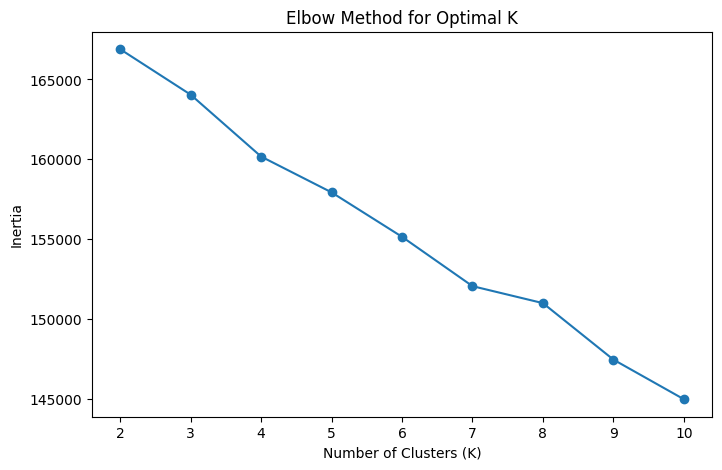

In [184]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(k_values)

plt.show()

In [185]:
%matplotlib inline

In [186]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(scaled_data)
    
    score = silhouette_score(
        scaled_data,
        cluster_labels
    )
    
    silhouette_scores.append(score)

print(silhouette_scores)

[0.32486666809500686, 0.05022816917026247, -0.00620917771537048, 0.021909671855161163, 0.031372280467856326, -0.019756885064776106, 0.06187939647077579, 0.0548184195141626, 0.061043647216398086]


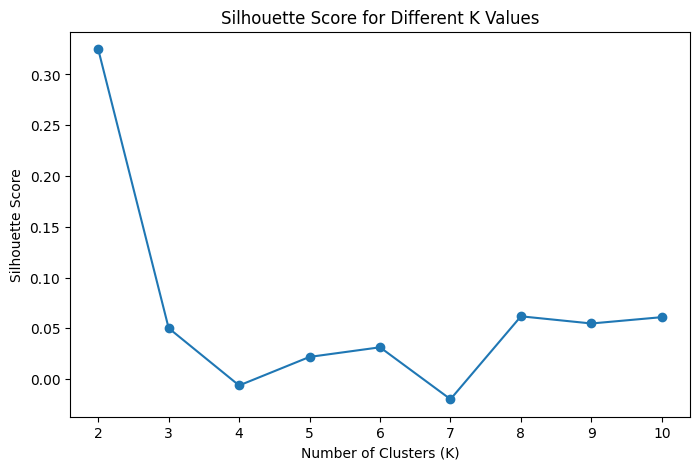

In [187]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(k_values)

plt.show()

In [188]:
# step 12-- Apply final K-Means Clustering

In [189]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)    

In [190]:
final_data["cluster"] = final_kmeans.fit_predict(scaled_data)

In [191]:
final_data[["client_id", "age", "total_investment", "average_property_price", "cluster"]].head(10)

,client_id,age,total_investment,average_property_price,cluster
0,C0001,58,1246764.72,311691.180000,1
1,C0002,63,1841095.93,368219.186000,1
2,C0003,67,1661457.59,332291.518000,1
3,C0004,66,1608263.51,268043.918333,1
4,C0005,50,3653385.38,281029.644615,1
5,C0006,69,1514131.06,302826.212000,1
6,C0007,79,3251147.83,295558.893636,1
7,C0008,56,1476730.41,295346.082000,1
8,C0009,50,1820832.35,364166.470000,1
9,C0010,60,1732434.00,346486.800000,1


In [192]:
final_data["cluster"].value_counts().sort_index()

cluster
0     337
1    1663
Name: count, dtype: int64

In [193]:
# Step-13. Analyze the Buyer Sgments

In [194]:
cluster_summary = final_data.groupby("cluster").agg(
    buyers=("client_id", "count"),
    average_age=("age", "mean"),
    average_satisfaction=("satisfaction_score", "mean"),
    average_properties=("number_of_properties", "mean"),
    average_total_investment=("total_investment", "mean"),
    average_property_price=("average_property_price","mean"),
    average_floor_area=("average_floor_area", "mean")
).reset_index()    

In [195]:
cluster_summary

,cluster,buyers,average_age,average_satisfaction,average_properties,average_total_investment,average_property_price,average_floor_area
0,0,337,53.931751,2.982196,3.563798,1.227374e+06,345627.119692,1143.815522
1,1,1663,56.129886,3.038485,3.670475,1.267063e+06,347386.393507,1148.222192


In [196]:
cluster_summary = cluster_summary.round(2)

In [197]:
cluster_summary

,cluster,buyers,average_age,average_satisfaction,average_properties,average_total_investment,average_property_price,average_floor_area
0,0,337,53.93,2.98,3.56,1227374.36,345627.12,1143.82
1,1,1663,56.13,3.04,3.67,1267063.02,347386.39,1148.22


In [198]:
pd.crosstab(
    final_data["cluster"],
    final_data["acquisition_purpose"],
    normalize ="index"
).round(2)
        

acquisition_purpose,Home,Investment
cluster,,
0,0.71,0.29
1,0.69,0.31


In [199]:
pd.crosstab(
    final_data["cluster"],
    final_data["loan_applied"],
    normalize ="index"
).round(2)

loan_applied,No,Yes
cluster,,
0,0.64,0.36
1,0.63,0.37


In [200]:
pd.crosstab(
    final_data["cluster"],
    final_data["client_type"],
    normalize ="index"
).round(2)

client_type,Company,Individual
cluster,,
0,0.05,0.95
1,0.05,0.95


In [ ]:
# Srep-14 : Understand and Name the Buyer Segments

In [202]:
cluster_summary

,cluster,buyers,average_age,average_satisfaction,average_properties,average_total_investment,average_property_price,average_floor_area
0,0,337,53.93,2.98,3.56,1227374.36,345627.12,1143.82
1,1,1663,56.13,3.04,3.67,1267063.02,347386.39,1148.22


In [204]:
print("Cluster 0:")
print(cluster_summary[cluster_summary["cluster"] == 0])

print("\nCluster 1:")
print(cluster_summary[cluster_summary["cluster"] == 1])

Cluster 0:
   cluster  buyers  average_age  average_satisfaction  average_properties  \
0        0     337        53.93                  2.98                3.56   

   average_total_investment  average_property_price  average_floor_area  
0                1227374.36               345627.12             1143.82  

Cluster 1:
   cluster  buyers  average_age  average_satisfaction  average_properties  \
1        1    1663        56.13                  3.04                3.67   

   average_total_investment  average_property_price  average_floor_area  
1                1267063.02               347386.39             1148.22  


In [207]:
cluster_summary[
    ["cluster", "average_total_investment", "average_properties", "average_property_price"]
    ]  

,cluster,average_total_investment,average_properties,average_property_price
0,0,1227374.36,3.56,345627.12
1,1,1267063.02,3.67,347386.39


In [209]:
pd.crosstab(
    final_data["cluster"],
    final_data["acquisition_purpose"],
    normalize="index"
).round(2)    

acquisition_purpose,Home,Investment
cluster,,
0,0.71,0.29
1,0.69,0.31


In [210]:
pd.crosstab(
    final_data["cluster"],
    final_data["loan_applied"],
    normalize="index"
).round(2)    

loan_applied,No,Yes
cluster,,
0,0.64,0.36
1,0.63,0.37


In [211]:
pd.crosstab(
    final_data["cluster"],
    final_data["client_type"],
    normalize="index"
).round(2)    
    

client_type,Company,Individual
cluster,,
0,0.05,0.95
1,0.05,0.95


In [212]:
# Step-15 : Visualize the Buyer Segments

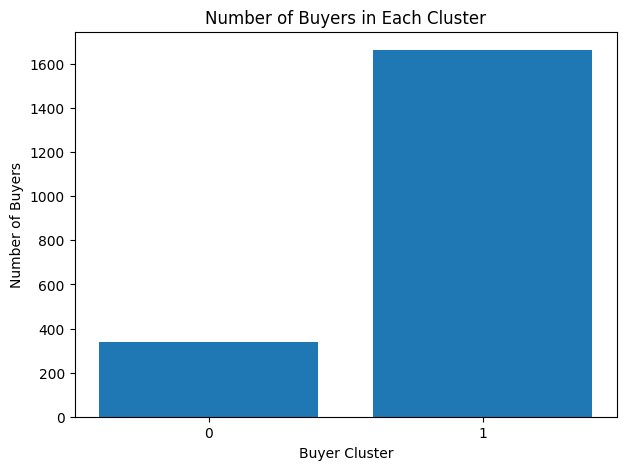

In [213]:
cluster_counts = final_data["cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)   

plt.xlabel("Buyer Cluster")
plt.ylabel("Number of Buyers")
plt.title("Number of Buyers in Each Cluster")

plt.show()

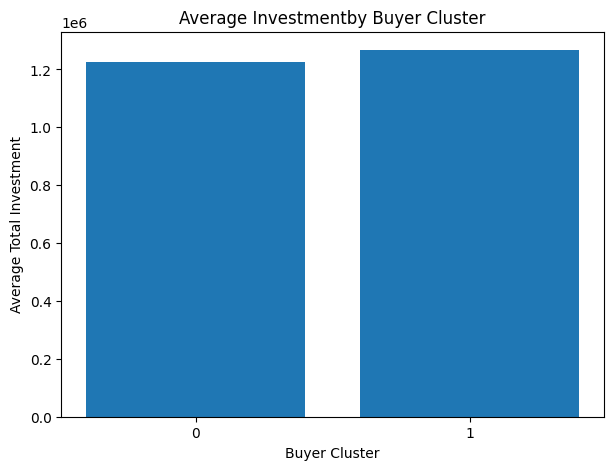

In [215]:
cluster_investment = final_data.groupby(
    "cluster"
)["total_investment"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    cluster_investment.index.astype(str),
    cluster_investment.values
)

plt.xlabel("Buyer Cluster")
plt.ylabel("Average Total Investment")
plt.title("Average Investmentby Buyer Cluster")

plt.show()

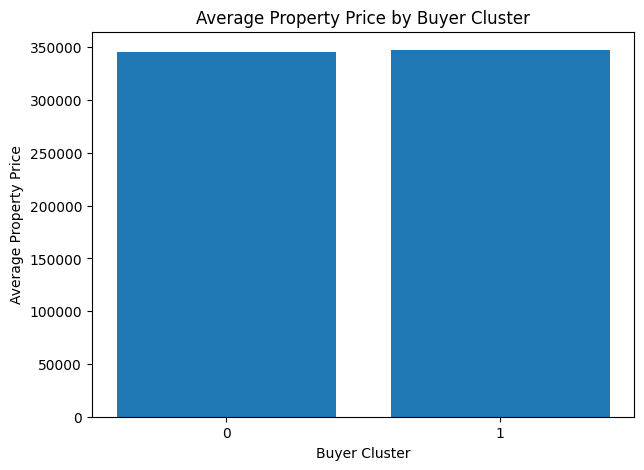

In [216]:
cluster_price = final_data.groupby(
    "cluster"
)["average_property_price"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    cluster_price.index.astype(str),
    cluster_price.values
)

plt.xlabel("Buyer Cluster")
plt.ylabel("Average Property Price")
plt.title("Average Property Price by Buyer Cluster")

plt.show()

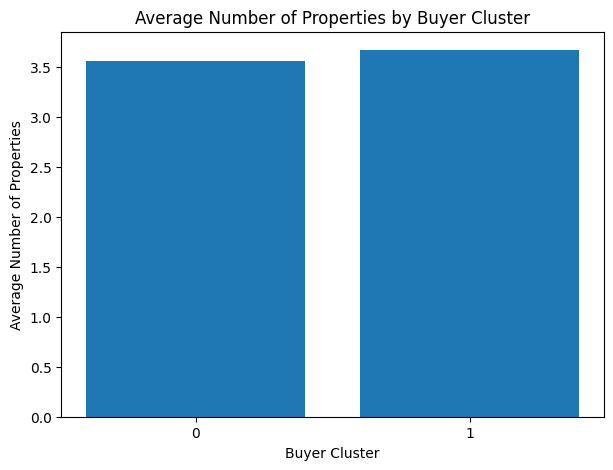

In [217]:
cluster_properties = final_data.groupby(
    "cluster"
)["number_of_properties"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    cluster_properties.index.astype(str),
    cluster_properties.values
)

plt.xlabel("Buyer Cluster")
plt.ylabel("Average Number of Properties")
plt.title("Average Number of Properties by Buyer Cluster")

plt.show()

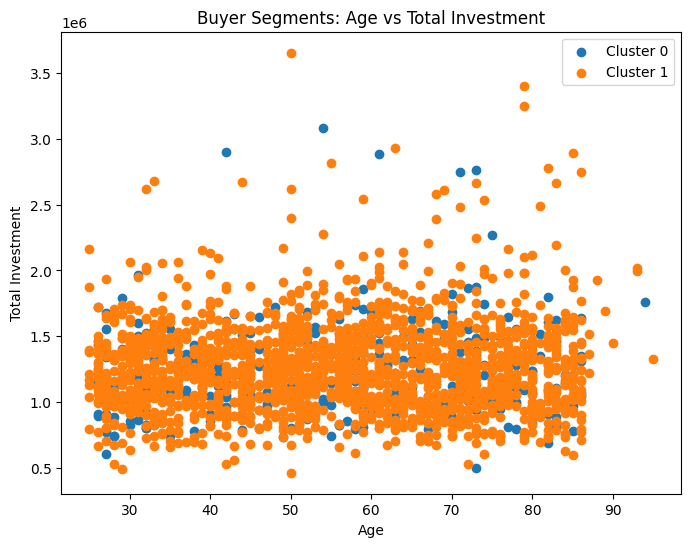

In [218]:
plt.figure(figsize=(8, 6))

for cluster in sorted(final_data["cluster"].unique()):
    cluster_data = final_data[
        final_data["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["age"],
        cluster_data["total_investment"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Age")
plt.ylabel("Total Investment")
plt.title("Buyer Segments: Age vs Total Investment")
plt.legend()

plt.show()

In [219]:
# Step-16 : Create the Final Buyer Degments Profile

In [220]:
segment_profile = final_data.groupby("cluster").agg(
    number_of_buyers=("client_id", "count"),
    average_age=("age", "mean"),
    average_satisfaction=("satisfaction_score", "mean"),
    average_properties=("number_of_properties", "mean"),
    average_total_investment=("total_investment", "mean"),
    average_property_price=("average_property_price", "mean"),
    average_floor_area=("average_floor_area", "mean")
).reset_index()
    

In [221]:
segment_profile = segment_profile.round(2)

In [222]:
segment_profile

,cluster,number_of_buyers,average_age,average_satisfaction,average_properties,average_total_investment,average_property_price,average_floor_area
0,0,337,53.93,2.98,3.56,1227374.36,345627.12,1143.82
1,1,1663,56.13,3.04,3.67,1267063.02,347386.39,1148.22


In [223]:
purpose_profile = pd.crosstab(
    final_data["cluster"],
    final_data["acquisition_purpose"],
    normalize="index"
).round(2)

purpose_profile

acquisition_purpose,Home,Investment
cluster,,
0,0.71,0.29
1,0.69,0.31


In [225]:
loan_profile = pd.crosstab(
    final_data["cluster"],
    final_data["loan_applied"],
    normalize="index"
).round(2)

loan_profile

loan_applied,No,Yes
cluster,,
0,0.64,0.36
1,0.63,0.37


In [226]:
client_type_profile = pd.crosstab(
    final_data["cluster"],
    final_data["client_type"],
    normalize="index"
).round(2)

client_type_profile

client_type,Company,Individual
cluster,,
0,0.05,0.95
1,0.05,0.95
